# Eddy Vertical Section

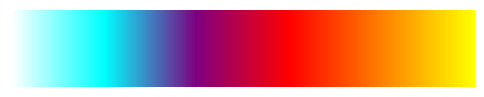

In [64]:
import sys
from goa_import import *
HOME='/oscar/data/deeps/private/ediloren/ebeaudin/'


# Custom colormap
import matplotlib.colors as mcolors
colors = [
    (1, 1, 1),            # white
    (0, 1, 1),            # cyan
    (0.5, 0, 0.5),        # purplish (dark purple)
    (1, 0, 0),            # red
    (1, 0.5, 0),          # orange
    (1, 1, 0),            # yellow
]
custom_cmap = mcolors.LinearSegmentedColormap.from_list('custom_w_c_p_r_o_y', colors)

# Visualize the colormap
fig, ax = plt.subplots(figsize=(6, 1))
ax.imshow(np.linspace(0, 1, 256).reshape(1, -1), aspect='auto', cmap=custom_cmap); ax.set_axis_off(); plt.show()


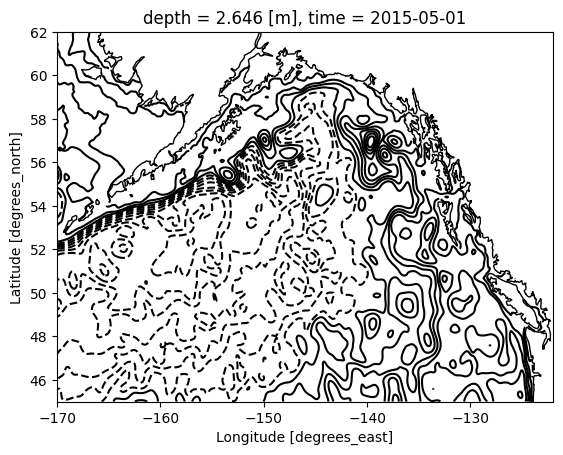

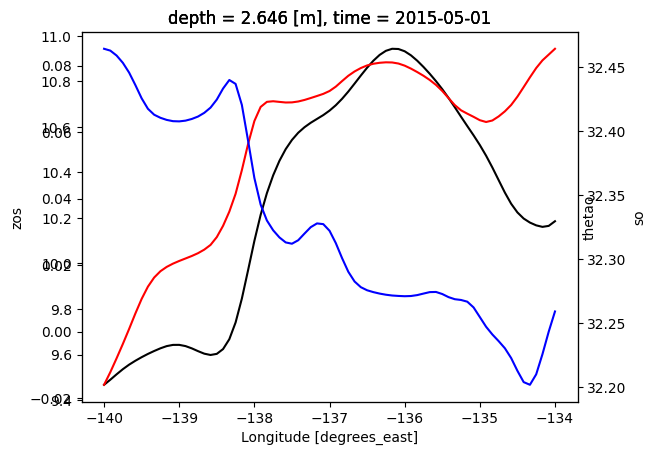

In [29]:
path=HOME+'data/GLORYS_daily/depth_2.65m/'
ds = xr.open_mfdataset(sorted(glob(path+'*.nc'))).isel(depth=0)

ds_mo = ds.resample(time='1MS').mean('time')
ds_mo.zos.sel(time='2015-05-01').plot.contour(colors='k',levels=20)
coastline()

plt.figure()
ds_mo.zos.sel(latitude=slice(49,51),longitude=slice(-140,-134),time='2015-05-01').mean('latitude').plot(color='k')
ds_mo.thetao.sel(latitude=slice(49,51),longitude=slice(-140,-134),time='2015-05-01').mean('latitude').plot(color='r',ax=plt.gca().twinx())
ds_mo.so.sel(latitude=slice(49,51),longitude=slice(-140,-134),time='2015-05-01').mean('latitude').plot(color='b',ax=plt.gca().twinx())

In [57]:
depths =  [0.5, 2.65, 5.08, 9.57, 21.6, 47.37, 92.33]
data_list = []

for depth in depths:
    path = f"{HOME}data/GLORYS_daily/depth_{depth}m/"
    ds = xr.open_mfdataset(sorted(glob.glob(path + "*.nc")), combine='by_coords').isel(depth=0)
    ds = ds.assign_coords(depth=depth)  # Replace depth with scalar
    ds_mo = ds.resample(time='1MS').mean('time')
    section = ds_mo.sel(latitude=slice(49, 51), longitude=slice(-145, -130), time='2015-05-01')
    section_mean = section.mean(dim='latitude')
    data_list.append(section_mean)

# Concatenate all datasets along a new depth dimension
ds_all = xr.concat(data_list, dim='depth')

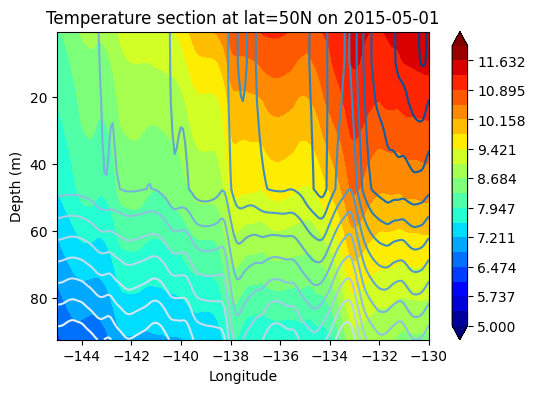

In [59]:
# Plot
plt.figure(figsize=(6,4))
plt.contourf(ds_all.longitude, depths, ds_all.thetao, 
             levels=np.linspace(5,12,20), cmap='jet',
             extend='both')
plt.colorbar()
plt.contour(ds_all.longitude, depths, ds_all.so, levels=20, cmap='Blues_r')
plt.gca().invert_yaxis()
plt.title('Temperature section at lat=50N on 2015-05-01')
plt.xlabel('Longitude')
plt.ylabel('Depth (m)')
plt.show();

In [92]:
# Kelvin Waves
lat_range = slice(45, 52)  # Gulf of Alaska coast
lon_range = slice(-128, -122)  #
ds = xr.open_mfdataset(sorted(glob(path+'*.nc'))) # your usual GLORYS loader
ssh_coast = ds.zos.sel(longitude=lon_range, 
                       latitude=lat_range).mean('longitude').chunk({'time':1}).load()

In [100]:
# Detrend and bandpass filter
from scipy.signal import butter, filtfilt

def bandpass_filter(data, low, high, fs):
    b, a = butter(2, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return xr.apply_ufunc(
        lambda x: filtfilt(b, a, x),
        data,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
    )

ssha = anomalies(ssh_coast)
ssh_filtered = bandpass_filter(ssha, low=1/90, high=1/10, fs=1)
#ssh_filtered

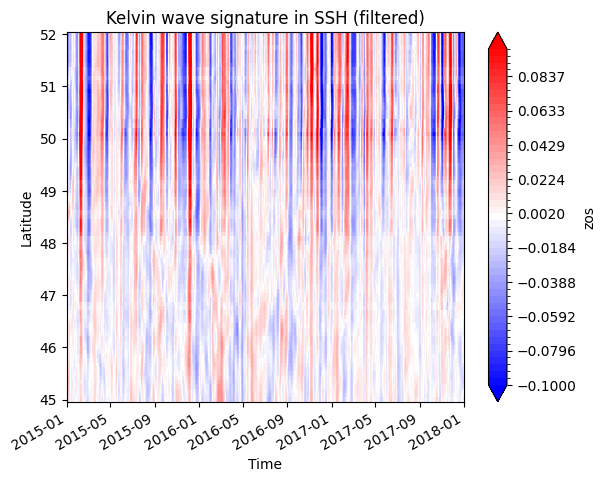

In [102]:
plt.figure()
ssh_filtered.plot(x='time', y='latitude', cmap='bwr', levels=np.linspace(-0.1,0.1,50))
plt.title('Kelvin wave signature in SSH (filtered)')
plt.ylabel('Latitude')
plt.xlabel('Time')
plt.xlim(pd.Timestamp('2015'),pd.Timestamp('2018'))
plt.show();